In [97]:
import jax.numpy as jnp
import numpy as np
import jax
import jax.random as jr

# Import the custom package you generated
from General_HMC import HMCSampler 
import matplotlib.pyplot as plt

num_dimensions = 50
num_data = 100
noise_magnitude_on_each_point = 0.1
total_length = 1
def matern_32(r, variance=1.0, scale=total_length/5, jitter=1e-6):
    result = variance * (1 + jnp.sqrt(3)*r/scale)*jnp.exp(-1*jnp.sqrt(3)*r/scale);
    return jnp.where(r > 0, result, result * (1.0 + jitter))

def dist_function(i, j):
    return jnp.abs(i - j)*total_length/(num_dimensions - 1)

fixed_points_linspace = jnp.linspace(0, total_length, num_dimensions)
shape = (num_dimensions, num_dimensions)
dist_matrix = jnp.fromfunction(dist_function, shape)
cov_prior_matrix = matern_32(dist_matrix)
inv_cov_prior_matrix = jnp.linalg.inv(cov_prior_matrix)


diagonal_values = jnp.ones(num_data)*noise_magnitude_on_each_point**2
cov_data_matrix = jnp.diag(diagonal_values)
inv_cov_data_matrix = jnp.linalg.inv(cov_data_matrix)

k1, k2 = jr.split(jr.key(90))
x_obs = jr.uniform(k1, shape=(num_data,), minval=0.0, maxval=total_length)
y_obs_true = jnp.sin(30*x_obs) * jnp.exp(-5*x_obs)
y_obs_err = noise_magnitude_on_each_point * jnp.ones_like(y_obs_true)

y_obs = y_obs_true + y_obs_err * jr.normal(k2, shape=y_obs_true.shape)

observed_indices = jnp.searchsorted(fixed_points_linspace, x_obs)

R = jnp.zeros((num_data, num_dimensions));
R = R.at[jnp.arange(num_data), observed_indices].set(1);


D = cov_prior_matrix - cov_prior_matrix @ R.T @ jnp.linalg.inv(R @ cov_prior_matrix @ R.T + cov_data_matrix) @ R @ cov_prior_matrix;
M = cov_prior_matrix @ R.T @ jnp.linalg.inv(R @ cov_prior_matrix @ R.T + cov_data_matrix) @ y_obs
L_D = jnp.linalg.cholesky(D)

def KL_div_between_two_Gaussians(x1, cov1, x2, cov2, num_dimensions):
    _, logabsdet1 = jnp.linalg.slogdet(cov1)
    _, logabsdet2 = jnp.linalg.slogdet(cov2)
    print(f"Log determinants: {logabsdet1} and {logabsdet2}")
    print(f"Trace inverse {jnp.linalg.trace(jnp.linalg.inv(cov2) @ cov1)}")
    print(f"Distance between means with cov2: {(x2 - x1).T @ jnp.linalg.inv(cov2) @ (x2 - x1)}")
    return 0.5*( logabsdet2 - logabsdet1
               - num_dimensions
                + jnp.linalg.trace(jnp.linalg.inv(cov2) @ cov1)
                + (x2 - x1).T @ jnp.linalg.inv(cov2) @ (x2 - x1))

In [98]:
num_overall_steps = 30000
burn_in = 200
def negative_logdensity(x):
    negative_log_p_d_given_s = 0.5*(y_obs - R @ x).T @ inv_cov_data_matrix @ (y_obs - R @ x) 
    negative_log_p_s = 0.5*x.T @ inv_cov_prior_matrix @ x
    return negative_log_p_d_given_s + negative_log_p_s

sampler = HMCSampler(
    negative_logdensity=negative_logdensity,
    num_integration_steps=40,
    step_size=0.025,
    inv_mass_matrix = jnp.eye(num_dimensions),
    alpha=1.0
)

# 3. Setup execution seed and coordinates, then run!
rng = jr.PRNGKey(1)
initial_coordinates = jnp.zeros(num_dimensions)

overall_position_arr, overall_momentum_arr, accept_prob_arr = sampler.sample(
    start_position=initial_coordinates, 
    num_samples=num_overall_steps,
    burn_in = burn_in,
    rng_key=rng
)


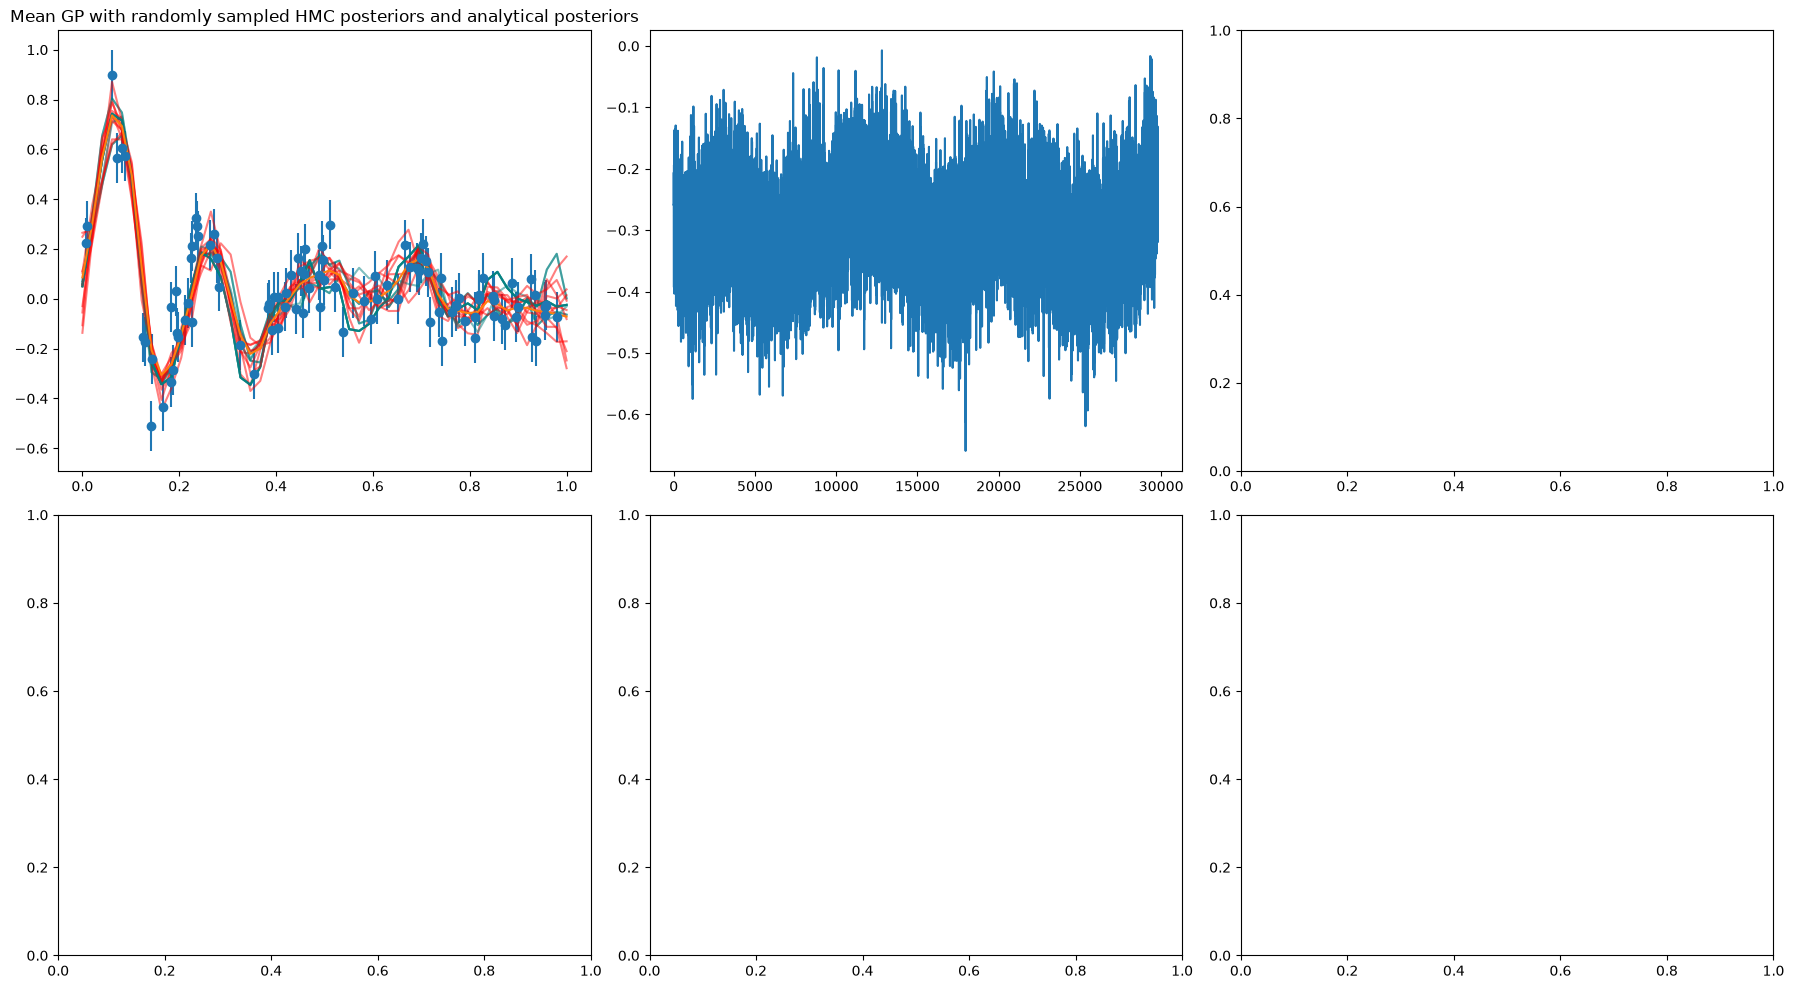

Log determinants: -309.96661376953125 and -310.5075378417969
Trace inverse 51.030906677246094
Distance between means with cov2: 0.14265821874141693
Log determinants: 0.0 and -0.49362677335739136
Trace inverse 51.03090286254883
Distance between means with cov2: 0.14265815913677216
KL_div using original mean/variances: 0.31632041931152344 Normalized KL_div: 0.3399676978588104
Covariance matrix of normalized HMC data (should be the identity): [[ 6.67293906e-01 -2.44404431e-02  2.51313038e-02 ... -2.09762808e-02
  -1.04878712e-02 -1.03036864e-02]
 [-2.44404431e-02  9.38716829e-01 -5.34962080e-02 ...  9.49179172e-04
   1.49245309e-02 -1.14465151e-02]
 [ 2.51313038e-02 -5.34962080e-02  9.28977907e-01 ... -2.47063534e-03
  -5.81934350e-03 -1.15755023e-02]
 ...
 [-2.09762808e-02  9.49179172e-04 -2.47063534e-03 ...  9.78372872e-01
   1.63428322e-03 -1.65940539e-04]
 [-1.04878731e-02  1.49245318e-02 -5.81934536e-03 ...  1.63428171e-03
   9.97912407e-01  6.82299910e-03]
 [-1.03036836e-02 -1.14465

In [99]:
num_good_samples = num_overall_steps - burn_in
rng, key = jr.split(rng)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0][0].errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')
noise = jr.normal(key, shape = (num_dimensions, num_overall_steps))
noise_sample_from_posterior_array = M[:, None] + L_D @ noise
for i in range (0, 10):
    axes[0][0].plot(fixed_points_linspace, overall_position_arr[i, :], color = "teal", alpha = 0.5);
    axes[0][0].plot(fixed_points_linspace, noise_sample_from_posterior_array[:, i], color = "red", alpha = 0.5)
axes[0][0].plot(fixed_points_linspace, M)
axes[0][0].set_title("Mean GP with randomly sampled HMC posteriors and analytical posteriors")

time_arr = jnp.arange(num_good_samples)
axes[0][1].plot(time_arr, overall_position_arr[:, 30] - overall_position_arr[:, 1])
plt.tight_layout()
plt.show()


HMC_sample_mean = jnp.average(overall_position_arr, axis=0)
cov_HMC_data = jnp.cov(overall_position_arr,rowvar = False)
normalized_HMC_data = (jnp.linalg.inv(L_D) @ (overall_position_arr.T - M[:, None])).T
mean_normalized_HMC_data = jnp.average(normalized_HMC_data, axis = 0)
cov_normalized_HMC_data = jnp.cov(normalized_HMC_data, rowvar = False)
cov_random_posterior_samples = jnp.cov(noise_sample_from_posterior_array.T, rowvar = False)
KL_div = KL_div_between_two_Gaussians(M, D, HMC_sample_mean, cov_HMC_data, num_dimensions)
KL_div_normalized = KL_div_between_two_Gaussians(jnp.zeros(num_dimensions), jnp.eye(num_dimensions), mean_normalized_HMC_data, cov_normalized_HMC_data, num_dimensions)
print(f"KL_div using original mean/variances: {KL_div} Normalized KL_div: {KL_div_normalized}")
print(f"Covariance matrix of normalized HMC data (should be the identity): {cov_normalized_HMC_data}")